In [ ]:
import torch
from transformers import TextStreamer
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_IM_START_TOKEN, DEFAULT_IM_END_TOKEN
from llava.conversation import conv_templates, SeparatorStyle
from llava.model.builder import load_pretrained_model
from llava.utils import disable_torch_init
from llava.mm_utils import process_images, tokenizer_image_token, get_model_name_from_path
from PIL import Image
import matplotlib.pyplot as plt

# ------------------------------------------------
# User settings
# ------------------------------------------------
model_path = "liuhaotian/llava-v1.5-13b"  # 13B model
device = "cuda"  ## ***with "cuda" it uses multiple gpu automatically if it detects , cuda:0 forces to use 1st gpu
temperature = 0.2
max_new_tokens = 512

# ------------------------------------------------
# Load model (no quantization, FP16)
# ------------------------------------------------
disable_torch_init()
model_name = get_model_name_from_path(model_path)

tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path=model_path,
    model_base=None,
    model_name=model_name,
    load_8bit=False,
    load_4bit=False,
    device=device
)

# ------------------------------------------------
# Pick conversation template
# ------------------------------------------------
if "llama-2" in model_name.lower():
    conv_mode = "llava_llama_2"
elif "mistral" in model_name.lower():
    conv_mode = "mistral_instruct"
elif "v1.6-34b" in model_name.lower():
    conv_mode = "chatml_direct"
elif "v1" in model_name.lower():
    conv_mode = "llava_v1"
elif "mpt" in model_name.lower():
    conv_mode = "mpt"
else:
    conv_mode = "llava_v0"

conv = conv_templates[conv_mode].copy()
roles = ('user', 'assistant') if "mpt" in model_name.lower() else conv.roles

# ------------------------------------------------
# Function to run LLaVA on an image and text query
# ------------------------------------------------
def chat_with_image_query(image_file: str, prompt: str):
    """Pass image path and user query, returns assistant response."""
    
    # Load and process image
    image = Image.open(image_file).convert("RGB")
    image_size = image.size
    image_tensor = process_images([image], image_processor, model.config)
    if isinstance(image_tensor, list):
        image_tensor = [im.to(model.device, dtype=torch.float16) for im in image_tensor]
    else:
        image_tensor = image_tensor.to(model.device, dtype=torch.float16)
    
    # Display image
    plt.imshow(image)
    plt.axis("off")
    plt.show()
    
    # Print user query
    print(f"\nUser: {prompt}\n")
    
    # Pick a new conversation object to avoid old messages
    conv_session = conv_templates[conv_mode].copy()
    
    # Insert image token for first turn
    if model.config.mm_use_im_start_end:
        prompt_full = DEFAULT_IM_START_TOKEN + DEFAULT_IMAGE_TOKEN + DEFAULT_IM_END_TOKEN + "\n" + prompt
    else:
        prompt_full = DEFAULT_IMAGE_TOKEN + "\n" + prompt

    conv_session.append_message(conv_session.roles[0], prompt_full)
    conv_session.append_message(conv_session.roles[1], None)
    full_prompt = conv_session.get_prompt()

    input_ids = tokenizer_image_token(full_prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors="pt").unsqueeze(0).to(model.device)
    streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

    # Generate response
    with torch.inference_mode():
        output_ids = model.generate(
            input_ids,
            images=image_tensor,
            image_sizes=[image_size],
            do_sample=True if temperature > 0 else False,
            temperature=temperature,
            max_new_tokens=max_new_tokens,
            streamer=streamer,
            use_cache=True,
        )

    output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
    
    # Print assistant response
    print(f"Assistant: {output_text}\n")
    return output_text



def chat_with_multiple_images(image_files: list, prompt: str):
    """Pass a list of image paths and user query, returns assistant response."""
    
    # Load and process images
    images = [Image.open(f).convert("RGB") for f in image_files]
    image_sizes = [im.size for im in images]
    image_tensors = process_images(images, image_processor, model.config)
    if isinstance(image_tensors, list):
        image_tensors = [im.to(model.device, dtype=torch.float16) for im in image_tensors]
    else:
        image_tensors = image_tensors.to(model.device, dtype=torch.float16)
    
    # Display all images
    fig, axes = plt.subplots(1, len(images), figsize=(5*len(images), 5))
    if len(images) == 1:
        axes = [axes]
    for ax, im in zip(axes, images):
        ax.imshow(im)
        ax.axis("off")
    plt.show()
    
    # Prepare prompt with one image token per image
    prompt_full = ""
    for _ in images:
        if model.config.mm_use_im_start_end:
            prompt_full += DEFAULT_IM_START_TOKEN + DEFAULT_IMAGE_TOKEN + DEFAULT_IM_END_TOKEN + "\n"
        else:
            prompt_full += DEFAULT_IMAGE_TOKEN + "\n"
    prompt_full += prompt
    
    # Create conversation session
    conv_session = conv_templates[conv_mode].copy()
    conv_session.append_message(conv_session.roles[0], prompt_full)
    conv_session.append_message(conv_session.roles[1], None)
    full_prompt = conv_session.get_prompt()
    
    # Tokenize
    input_ids = tokenizer_image_token(full_prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors="pt").unsqueeze(0).to(model.device)
    streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
    
    # Generate response
    with torch.inference_mode():
        output_ids = model.generate(
            input_ids,
            images=image_tensors,
            image_sizes=image_sizes,
            do_sample=True if temperature > 0 else False,
            temperature=temperature,
            max_new_tokens=max_new_tokens,
            streamer=streamer,
            use_cache=True,
        )
    
    output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
    
    # Print assistant response
    print(f"\nAssistant: {output_text}\n")
    return output_text
# ------------------------------------------------
# Example usage
# ------------------------------------------------

##BTW in LLAVA we can keep our old converstion continnue for single image, just here im resetting it for each text query

/scratch/codepk37/condaenv/llava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch/codepk37/condaenv/llava/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/scratch/codepk37/condaenv/llava/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards:   0%|       

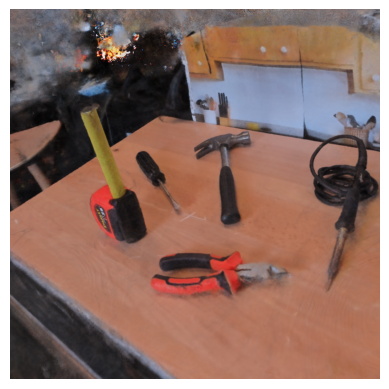


User: Describe best object from image provided in 2-3 words with its colour which can be used for execution of query  : The object you would pick to hang a picture, not the one that loosens screws

Hammer
Assistant: Hammer



In [17]:
image_path = "./renders/my_render.png"
query_text = "Describe best object from image provided in 2-3 words with its colour which can be used for execution of query  : The object you would pick to hang a picture, not the one that loosens screws" 

response = chat_with_image_query(image_path, query_text)

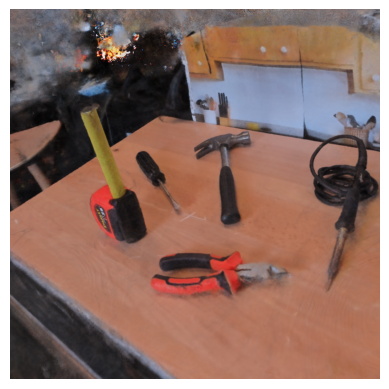


User: Describe object in 2-3 words with object property and colour like blue mug,which can be used for execution of query : Used to bend a wire or remove a small nail

Pliers
Assistant: Pliers



In [4]:
image_path = "./renders/my_render.png"
query_text = "Describe object in 2-3 words with object property and colour like blue mug,which can be used for execution of query : Used to bend a wire or remove a small nail" 

response = chat_with_image_query(image_path, query_text)

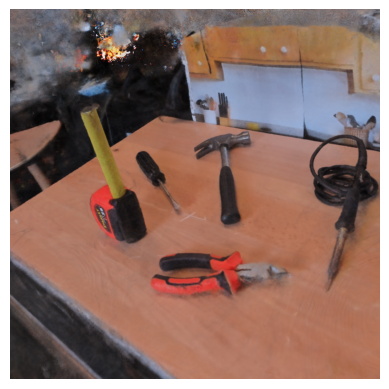


User: Describe object in 2-3 words with object property and colour like blue mug ,which can be used for execution of query : what can i use if i want to attach two wires permanently after heating them up

Wire cutter
Assistant: Wire cutter



In [5]:
image_path = "./renders/my_render.png"
query_text = "Describe object in 2-3 words with object property and colour like blue mug ,which can be used for execution of query : what can i use if i want to attach two wires permanently after heating them up" 

response = chat_with_image_query(image_path, query_text)

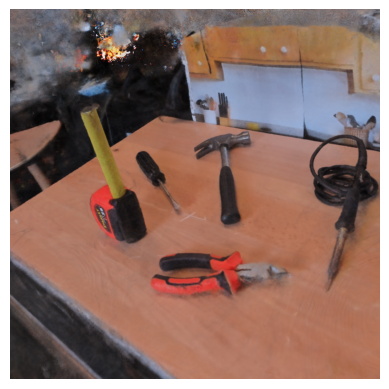


User: Describe object in 2-3 words with object property and colour like blue mug,which can be used for execution of query : How can i measure length of my bedroom

Tape measure
Assistant: Tape measure



In [6]:
image_path = "./renders/my_render.png"
query_text = "Describe object in 2-3 words with object property and colour like blue mug,which can be used for execution of query : How can i measure length of my bedroom" 

response = chat_with_image_query(image_path, query_text)

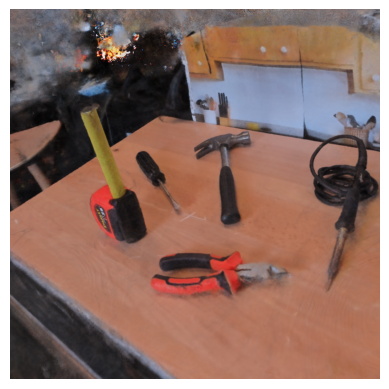


User: Describe object in 2-3 words with object property and colour like 'blue mug',which can be used for execution of query : which tool can i use to rotate screws and fix them in wall

Screwdriver
Assistant: Screwdriver



In [18]:
image_path = "./renders/my_render.png"
query_text = "Describe object in 2-3 words with object property and colour like 'blue mug',which can be used for execution of query : which tool can i use to rotate screws and fix them in wall" 

response = chat_with_image_query(image_path, query_text)